# Foveated VOneNet with DINO-ViT Saliency Oracle — Tiny-ImageNet

**Master's Thesis Experiment**

A biologically inspired image classifier that:
1. Uses a frozen DINO ViT-S/8 to extract saliency maps
2. Detects up to 3 salient regions → candidate fovea circles
3. Passes the image through a frozen VOneBlock (Gabor-based V1 simulation)
4. Applies trace-based Gaussian noise that increases with eccentricity from the fovea
5. Feeds degraded features into a ResNet-18 backend classifier

**Architecture:**
```
Image (3×224×224)
  ├─→ DINO ViT-S/8 (frozen) → saliency → up to 3 fovea circles
  │     training: random pick | eval: top-1
  └─→ VOneBlock (frozen, noise_mode=None)
        → features (B, 512, 56, 56)
        → TraceRadialNoise (0 inside fovea, increasing outside)
        → Bottleneck 1×1 (512→64)
        → ResNet18 backend → 200 classes
```

Robustness evaluation on Tiny-ImageNet-C (15 corruptions × 5 severities).

## 1. Environment Setup

In [ ]:
# Install required packages
!pip install -q timm scipy scikit-image

# Clone external repos for reference
import os
os.makedirs('/content/external', exist_ok=True)

if not os.path.exists('/content/external/vonenet'):
    !git clone --depth 1 https://github.com/dicarlolab/vonenet.git /content/external/vonenet

if not os.path.exists('/content/external/dino-vit-features'):
    !git clone --depth 1 https://github.com/ShirAmir/dino-vit-features.git /content/external/dino-vit-features

# Create output directories
os.makedirs('/content/outputs', exist_ok=True)
os.makedirs('/content/checkpoints', exist_ok=True)

import sys
sys.path.insert(0, '/content/external/vonenet')
sys.path.insert(0, '/content/external/dino-vit-features')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
from torch.cuda.amp import autocast, GradScaler
import scipy.ndimage
from collections import OrderedDict
import time
import math
import warnings
warnings.filterwarnings('ignore')

print(f'PyTorch: {torch.__version__}')
print(f'Torchvision: {torchvision.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

Cloning into '/content/external/vonenet'...
remote: Enumerating objects: 15, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (15/15), done.
remote: Total 15 (delta 0), reused 9 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (15/15), 301.62 KiB | 37.70 MiB/s, done.
Cloning into '/content/external/dino-vit-features'...
remote: Enumerating objects: 21, done.
remote: Counting objects: 100% (21/21), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 21 (delta 3), reused 11 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (21/21), 5.15 MiB | 23.75 MiB/s, done.
Resolving deltas: 100% (3/3), done.
PyTorch: 2.10.0+cu128
Torchvision: 0.25.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB
VRAM: 39.5 GB


## 2. Configuration

In [ ]:
from dataclasses import dataclass, field
from typing import List

@dataclass
class Config:
    # General
    seed: int = 42
    image_size: int = 224
    batch_size: int = 128
    epochs: int = 50
    learning_rate: float = 0.05
    num_workers: int = 4
    num_classes: int = 200

    # Backend
    backend: str = 'resnet18'  # 'resnet18' or 'resnet34'

    # VOneBlock
    simple_channels: int = 256
    complex_channels: int = 256
    ksize: int = 25
    stride: int = 4
    k_exc: float = 25.0
    visual_degrees: float = 8.0
    gabor_seed: int = 0
    freeze_vone: bool = True

    # DINO saliency oracle
    dino_model: str = 'dino_vits8'
    freeze_dino: bool = True

    # Fovea extraction
    num_salient_regions_max: int = 3
    saliency_threshold: float = 0.4
    min_region_area: int = 25
    min_center_distance: float = 0.2  # normalized [0,1]
    fovea_radius_scale: float = 1.0

    # Trace-based radial noise
    target_snr: float = 10.0
    radial_schedule: str = 'linear'  # 'linear', 'quadratic', 'exponential'
    invert_fovea: bool = False

    # Training
    mixed_precision: bool = True
    train_subset_debug: bool = False  # Set False for full training
    debug_num_classes: int = 10
    warmup_epochs: int = 5
    weight_decay: float = 1e-4
    momentum: float = 0.9

    # Paths
    tiny_imagenet_path: str = '/content/data/tiny-imagenet-200'
    tiny_imagenet_c_path: str = '/content/data/Tiny-ImageNet-C'
    checkpoint_dir: str = '/content/checkpoints'
    output_dir: str = '/content/outputs'

cfg = Config()

def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(cfg.seed)
print(f'Config: debug={cfg.train_subset_debug}, epochs={cfg.epochs}, '
      f'batch_size={cfg.batch_size}, schedule={cfg.radial_schedule}')

Config: debug=False, epochs=50, batch_size=128, schedule=linear


## 3. Dataset Preparation — Tiny-ImageNet

In [ ]:
import shutil
import glob

def download_tiny_imagenet(root):
    """Download and extract Tiny-ImageNet-200 if not present."""
    data_dir = os.path.dirname(root)
    os.makedirs(data_dir, exist_ok=True)
    if os.path.exists(root):
        print(f'Tiny-ImageNet already exists at {root}')
        return
    url = 'http://cs231n.stanford.edu/tiny-imagenet-200.zip'
    zip_path = os.path.join(data_dir, 'tiny-imagenet-200.zip')
    print(f'Downloading Tiny-ImageNet from {url}...')
    !wget -q -O {zip_path} {url}
    print('Extracting...')
    !unzip -q {zip_path} -d {data_dir}
    os.remove(zip_path)
    print('Done.')

def restructure_val_folder(val_dir):
    """Restructure Tiny-ImageNet val folder into class subdirectories for ImageFolder."""
    annotations_file = os.path.join(val_dir, 'val_annotations.txt')
    if not os.path.exists(annotations_file):
        print('Val folder already restructured or annotations missing.')
        return
    # Check if already restructured (class folders exist)
    images_dir = os.path.join(val_dir, 'images')
    if not os.path.exists(images_dir):
        print('Val folder already restructured.')
        return

    print('Restructuring val folder...')
    with open(annotations_file, 'r') as f:
        for line in f:
            parts = line.strip().split('\t')
            img_name, class_id = parts[0], parts[1]
            class_dir = os.path.join(val_dir, class_id, 'images')
            os.makedirs(class_dir, exist_ok=True)
            src = os.path.join(images_dir, img_name)
            dst = os.path.join(class_dir, img_name)
            if os.path.exists(src):
                shutil.move(src, dst)
    # Clean up
    if os.path.exists(images_dir) and len(os.listdir(images_dir)) == 0:
        shutil.rmtree(images_dir)
    if os.path.exists(annotations_file):
        os.remove(annotations_file)
    print('Val folder restructured.')

def get_dataloaders(cfg):
    """Create train and val dataloaders for Tiny-ImageNet."""
    download_tiny_imagenet(cfg.tiny_imagenet_path)
    val_dir = os.path.join(cfg.tiny_imagenet_path, 'val')
    restructure_val_folder(val_dir)

    mean = (0.485, 0.456, 0.406)
    std = (0.229, 0.224, 0.225)

    train_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.RandomCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])
    val_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    train_dir = os.path.join(cfg.tiny_imagenet_path, 'train')
    train_dataset = torchvision.datasets.ImageFolder(train_dir, transform=train_transform)
    val_dataset = torchvision.datasets.ImageFolder(val_dir, transform=val_transform)

    # Debug subset: use only first N classes
    if cfg.train_subset_debug:
        classes = sorted(train_dataset.classes)[:cfg.debug_num_classes]
        class_to_idx = {c: train_dataset.class_to_idx[c] for c in classes}
        valid_indices_train = [i for i, (_, label) in enumerate(train_dataset.samples)
                               if label in class_to_idx.values()]
        valid_indices_val = [i for i, (_, label) in enumerate(val_dataset.samples)
                            if label in class_to_idx.values()]
        train_dataset = Subset(train_dataset, valid_indices_train)
        val_dataset = Subset(val_dataset, valid_indices_val)
        effective_classes = cfg.debug_num_classes
        print(f'DEBUG MODE: Using {effective_classes} classes, '
              f'{len(train_dataset)} train / {len(val_dataset)} val images')
    else:
        effective_classes = cfg.num_classes
        print(f'FULL MODE: {effective_classes} classes, '
              f'{len(train_dataset)} train / {len(val_dataset)} val images')

    train_loader = DataLoader(
        train_dataset, batch_size=cfg.batch_size, shuffle=True,
        num_workers=cfg.num_workers, pin_memory=True, drop_last=True)
    val_loader = DataLoader(
        val_dataset, batch_size=cfg.batch_size * 2, shuffle=False,
        num_workers=cfg.num_workers, pin_memory=True)

    return train_loader, val_loader, effective_classes

train_loader, val_loader, effective_classes = get_dataloaders(cfg)
# Update num_classes if in debug mode
if cfg.train_subset_debug:
    cfg.num_classes = effective_classes

Extracting...
Done.
Restructuring val folder...
Val folder restructured.
FULL MODE: 200 classes, 100000 train / 10000 val images


## 4. Tiny-ImageNet-C Evaluation Utility

In [ ]:
CORRUPTIONS = [
    'gaussian_noise', 'shot_noise', 'impulse_noise', 'defocus_blur',
    'glass_blur', 'motion_blur', 'zoom_blur', 'snow', 'frost', 'fog',
    'brightness', 'contrast', 'elastic_transform', 'pixelate', 'jpeg_compression'
]


def download_tiny_imagenet_c(root):
    """Download and extract Tiny-ImageNet-C from Zenodo if not present."""
    if os.path.exists(root):
        print(f'Tiny-ImageNet-C already exists at {root}')
        return
    data_dir = os.path.dirname(root)
    os.makedirs(data_dir, exist_ok=True)
    tar_path = os.path.join(data_dir, 'Tiny-ImageNet-C.tar')

    # Zenodo direct download link
    url = 'https://zenodo.org/records/2536630/files/Tiny-ImageNet-C.tar'
    print(f'Downloading Tiny-ImageNet-C from Zenodo (~1.2 GB)...')
    print(f'URL: {url}')
    ret = os.system(f'wget -q --show-progress -O "{tar_path}" "{url}"')
    if ret != 0:
        # Fallback: try with curl
        print('wget failed, trying curl...')
        ret = os.system(f'curl -L -o "{tar_path}" "{url}"')
    if ret != 0 or not os.path.exists(tar_path):
        print('⚠ Download failed. You can manually download from:')
        print(f'  {url}')
        print(f'  Then extract to: {root}/')
        return

    print('Extracting...')
    os.system(f'tar -xf "{tar_path}" -C "{data_dir}"')

    # Handle possible nesting: if extracted to data_dir/Tiny-ImageNet-C check it
    extracted = os.path.join(data_dir, 'Tiny-ImageNet-C')
    if not os.path.exists(root) and os.path.exists(extracted):
        os.rename(extracted, root)
    elif not os.path.exists(root):
        # Try to find the extracted folder
        for name in os.listdir(data_dir):
            candidate = os.path.join(data_dir, name)
            if os.path.isdir(candidate) and 'gaussian_noise' in os.listdir(candidate):
                os.rename(candidate, root)
                break

    if os.path.exists(tar_path):
        os.remove(tar_path)
        print('Removed tar file to save space.')

    if os.path.exists(root):
        print(f'Tiny-ImageNet-C ready at {root}')
    else:
        print(f'⚠ Extraction may have failed. Check {data_dir} manually.')


def get_tinyimagenetc_loader(cfg, corruption, severity, valid_classes=None):
    """Load a single corruption/severity split of Tiny-ImageNet-C.
    If valid_classes is provided, only load images from those class folders."""
    corruption_dir = os.path.join(cfg.tiny_imagenet_c_path, corruption, str(severity))
    if not os.path.exists(corruption_dir):
        return None

    mean = (0.485, 0.456, 0.406)
    std = (0.229, 0.224, 0.225)
    transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    dataset = torchvision.datasets.ImageFolder(corruption_dir, transform=transform)

    # Filter to valid classes if in debug mode
    if valid_classes is not None:
        # Map valid class names to dataset indices
        valid_class_indices = set()
        for cls_name in valid_classes:
            if cls_name in dataset.class_to_idx:
                valid_class_indices.add(dataset.class_to_idx[cls_name])

        # Remap labels: TI-C dataset has all 200 classes indexed 0-199,
        # but our model only outputs debug_num_classes logits (0 to N-1).
        # We need to remap TI-C class indices to match training class order.
        valid_classes_sorted = sorted(valid_classes)
        remap = {dataset.class_to_idx[c]: i for i, c in enumerate(valid_classes_sorted)
                 if c in dataset.class_to_idx}

        # Filter samples to only valid classes and remap labels
        filtered_samples = [(path, remap[label]) for path, label in dataset.samples
                           if label in valid_class_indices]
        dataset.samples = filtered_samples
        dataset.targets = [s[1] for s in filtered_samples]
        dataset.imgs = filtered_samples

        if len(dataset) == 0:
            return None

    loader = DataLoader(dataset, batch_size=cfg.batch_size * 2, shuffle=False,
                        num_workers=cfg.num_workers, pin_memory=True)
    return loader


def evaluate_tinyimagenetc(model, saliency_oracle, cfg, fovea_fn):
    """Evaluate model on all available Tiny-ImageNet-C corruptions.
    Returns dict {corruption: {severity: accuracy}} or None if data not found."""
    # Auto-download if missing
    if not os.path.exists(cfg.tiny_imagenet_c_path):
        print('Tiny-ImageNet-C not found locally. Attempting download...')
        download_tiny_imagenet_c(cfg.tiny_imagenet_c_path)

    if not os.path.exists(cfg.tiny_imagenet_c_path):
        print(f'\n⚠ Tiny-ImageNet-C still not available at {cfg.tiny_imagenet_c_path}')
        print('  Skipping corruption evaluation.')
        return None

    # Determine valid classes for debug mode
    valid_classes = None
    if cfg.train_subset_debug:
        # Reconstruct which classes were used in training
        train_dir = os.path.join(cfg.tiny_imagenet_path, 'train')
        if os.path.exists(train_dir):
            all_classes = sorted(os.listdir(train_dir))
            all_classes = [c for c in all_classes if os.path.isdir(os.path.join(train_dir, c))]
            valid_classes = sorted(all_classes)[:cfg.debug_num_classes]
            print(f'Debug mode: evaluating on {len(valid_classes)} classes only')

    model.eval()
    results = {}

    for corruption in CORRUPTIONS:
        results[corruption] = {}
        for severity in range(1, 6):
            loader = get_tinyimagenetc_loader(cfg, corruption, severity, valid_classes)
            if loader is None:
                continue
            correct = 0
            total = 0
            with torch.no_grad():
                for images, labels in loader:
                    images, labels = images.to(device), labels.to(device)
                    fovea_circles = fovea_fn(images, saliency_oracle, cfg, training=False)
                    logits = model(images, fovea_circles)
                    preds = logits.argmax(dim=1)
                    correct += (preds == labels).sum().item()
                    total += labels.size(0)
            acc = correct / total if total > 0 else 0.0
            results[corruption][severity] = acc
        if results[corruption]:
            mean_acc = np.mean(list(results[corruption].values()))
            print(f'  {corruption:25s} | mean acc: {mean_acc:.4f}')

    return results

# Download Tiny-ImageNet-C now (so it's ready before evaluation)
download_tiny_imagenet_c(cfg.tiny_imagenet_c_path)
print('\nTiny-ImageNet-C evaluation utility ready.')

URL: https://zenodo.org/records/2536630/files/Tiny-ImageNet-C.tar
Extracting...
Removed tar file to save space.
Tiny-ImageNet-C ready at /content/data/Tiny-ImageNet-C

Tiny-ImageNet-C evaluation utility ready.


## 5. DINO-ViT Saliency Oracle

Uses a frozen DINO ViT-S/8 model. Extracts CLS-to-patch attention from the last transformer block, averaged over heads, and min-max normalized per sample.

In [ ]:
class SaliencyOracle(nn.Module):
    """Frozen DINO ViT-S/8 saliency extractor.
    Returns normalized saliency maps from CLS-to-patch attention."""

    def __init__(self, model_name='dino_vits8'):
        super().__init__()
        self.model = torch.hub.load('facebookresearch/dino:main', model_name)
        self.model.eval()
        for p in self.model.parameters():
            p.requires_grad = False

        self.patch_size = self.model.patch_embed.patch_size
        if isinstance(self.patch_size, tuple):
            self.patch_size = self.patch_size[0]
        self.num_heads = self.model.blocks[-1].attn.num_heads
        self._attn = None
        # Register hook on last block's attention
        self.model.blocks[-1].attn.attn_drop.register_forward_hook(self._hook_fn)

    def _hook_fn(self, module, input, output):
        self._attn = output  # (B, num_heads, N, N)

    @torch.no_grad()
    def forward(self, x, target_size=None):
        """Extract saliency map.
        Args:
            x: (B, 3, H, W) normalized images
            target_size: (h, w) to interpolate saliency to. If None, returns patch-grid size.
        Returns:
            saliency: (B, h, w) in [0, 1]
        """
        B, _, H, W = x.shape
        h_patches = H // self.patch_size
        w_patches = W // self.patch_size

        _ = self.model(x)  # triggers hook
        attn = self._attn  # (B, heads, N, N) where N = 1 + h_patches*w_patches

        # CLS token attention to patch tokens, mean over heads
        cls_attn = attn[:, :, 0, 1:]  # (B, heads, num_patches)
        saliency = cls_attn.mean(dim=1)  # (B, num_patches)

        # Reshape to 2D grid
        saliency = saliency.reshape(B, h_patches, w_patches)

        # Min-max normalize per sample
        s_min = saliency.flatten(1).min(dim=1).values[:, None, None]
        s_max = saliency.flatten(1).max(dim=1).values[:, None, None]
        saliency = (saliency - s_min) / (s_max - s_min + 1e-8)

        # Interpolate to target size if specified
        if target_size is not None:
            saliency = F.interpolate(
                saliency.unsqueeze(1), size=target_size,
                mode='bilinear', align_corners=False
            ).squeeze(1)

        return saliency

# Instantiate
saliency_oracle = SaliencyOracle(cfg.dino_model).to(device)
print(f'SaliencyOracle loaded: {cfg.dino_model}, patch_size={saliency_oracle.patch_size}')

Downloading: "https://github.com/facebookresearch/dino/zipball/main" to /root/.cache/torch/hub/main.zip
Downloading: "https://dl.fbaipublicfiles.com/dino/dino_deitsmall8_pretrain/dino_deitsmall8_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dino_deitsmall8_pretrain.pth


100%|██████████| 82.7M/82.7M [00:06<00:00, 13.0MB/s]


SaliencyOracle loaded: dino_vits8, patch_size=8


## 6. Saliency Segmentation into Candidate Fovea Circles

From the saliency map:
- Threshold → remove small blobs → connected components
- Rank by saliency mass → keep up to 3 regions
- Enforce minimum center distance
- Compute centroid and equivalent circular radius for each

In [ ]:
def extract_fovea_candidates(saliency_map, cfg):
    """Extract up to K candidate fovea circles from a single saliency map.

    Args:
        saliency_map: (H, W) numpy array in [0, 1]
        cfg: Config object

    Returns:
        List of (cx, cy, radius) tuples in normalized [0, 1] coordinates.
        cx, cy are center coordinates, radius is the equivalent circular radius.
    """
    H, W = saliency_map.shape

    # Threshold
    binary = (saliency_map >= cfg.saliency_threshold).astype(np.uint8)

    # Remove small blobs
    labeled, num_features = scipy.ndimage.label(binary)
    if num_features == 0:
        # Fallback: center of image with default radius
        return [(0.5, 0.5, 0.15)]

    # Compute properties for each component
    candidates = []
    for comp_id in range(1, num_features + 1):
        mask = (labeled == comp_id)
        area = mask.sum()
        if area < cfg.min_region_area:
            continue

        # Saliency mass and weighted centroid
        sal_mass = (saliency_map * mask).sum()
        ys, xs = np.where(mask)
        weights = saliency_map[ys, xs]
        cx = np.average(xs, weights=weights) / W  # normalize to [0, 1]
        cy = np.average(ys, weights=weights) / H

        # Equivalent circular radius (normalized)
        radius = np.sqrt(area / np.pi) / max(H, W) * cfg.fovea_radius_scale

        candidates.append((cx, cy, radius, sal_mass))

    if not candidates:
        return [(0.5, 0.5, 0.15)]

    # Sort by saliency mass (descending)
    candidates.sort(key=lambda x: x[3], reverse=True)

    # Select top K with minimum center distance enforcement
    selected = []
    for cx, cy, r, mass in candidates:
        if len(selected) >= cfg.num_salient_regions_max:
            break
        # Check distance to already selected centers
        too_close = False
        for sx, sy, sr in selected:
            dist = np.sqrt((cx - sx)**2 + (cy - sy)**2)
            if dist < cfg.min_center_distance:
                too_close = True
                break
        if not too_close:
            selected.append((cx, cy, r))

    if not selected:
        # Use top candidate ignoring distance
        cx, cy, r, _ = candidates[0]
        selected = [(cx, cy, r)]

    return selected


def batch_extract_fovea_candidates(saliency_maps, cfg):
    """Extract fovea candidates for a batch of saliency maps.
    Args:
        saliency_maps: (B, H, W) tensor or numpy
    Returns:
        List of lists of (cx, cy, r) tuples, one per sample.
    """
    if torch.is_tensor(saliency_maps):
        saliency_maps = saliency_maps.cpu().numpy()
    return [extract_fovea_candidates(s, cfg) for s in saliency_maps]


def select_fovea_for_batch(candidates_list, training=True):
    """Select one fovea circle per sample.
    Training: random selection. Eval: top-1 (first = highest saliency mass).
    Returns: list of (cx, cy, r) tuples, one per sample.
    """
    selected = []
    for cands in candidates_list:
        if training and len(cands) > 1:
            idx = np.random.randint(0, len(cands))
            selected.append(cands[idx])
        else:
            selected.append(cands[0])  # top-1
    return selected


def get_fovea_circles(images, saliency_oracle, cfg, training=True):
    """Full pipeline: images -> saliency -> fovea candidates -> selection.
    Returns list of (cx, cy, r) per sample."""
    with torch.no_grad():
        # Get saliency at a workable resolution
        saliency = saliency_oracle(images, target_size=(56, 56))
    candidates_list = batch_extract_fovea_candidates(saliency, cfg)
    return select_fovea_for_batch(candidates_list, training=training)


# --- Plotting helpers ---
def plot_fovea_analysis(images, saliency_maps, candidates_list, selected_circles,
                        n_show=4, save_path=None):
    """Visualize saliency analysis for a few samples."""
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    n_show = min(n_show, len(images))
    fig, axes = plt.subplots(n_show, 4, figsize=(16, 4*n_show))
    if n_show == 1:
        axes = axes[None, :]

    for i in range(n_show):
        img = images[i].cpu().numpy().transpose(1, 2, 0)
        img = (img * std + mean).clip(0, 1)
        sal = saliency_maps[i].cpu().numpy() if torch.is_tensor(saliency_maps[i]) else saliency_maps[i]

        # Original image
        axes[i, 0].imshow(img)
        axes[i, 0].set_title('Image')
        axes[i, 0].axis('off')

        # Saliency map
        axes[i, 1].imshow(sal, cmap='hot', interpolation='bilinear')
        axes[i, 1].set_title('Saliency Map')
        axes[i, 1].axis('off')

        # Candidates on image
        axes[i, 2].imshow(img)
        H_img, W_img = img.shape[:2]
        for j, (cx, cy, r) in enumerate(candidates_list[i]):
            circle = plt.Circle((cx * W_img, cy * H_img), r * max(H_img, W_img),
                               fill=False, color=['red', 'blue', 'green'][j % 3], linewidth=2)
            axes[i, 2].add_patch(circle)
            axes[i, 2].plot(cx * W_img, cy * H_img, 'x',
                           color=['red', 'blue', 'green'][j % 3], markersize=10)
        axes[i, 2].set_title(f'Candidates ({len(candidates_list[i])})')
        axes[i, 2].axis('off')

        # Selected fovea with circle
        axes[i, 3].imshow(img)
        cx, cy, r = selected_circles[i]
        circle = plt.Circle((cx * W_img, cy * H_img), r * max(H_img, W_img),
                           fill=False, color='lime', linewidth=3)
        axes[i, 3].add_patch(circle)
        axes[i, 3].set_title(f'Selected Fovea')
        axes[i, 3].axis('off')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=100, bbox_inches='tight')
    plt.show()

print('Fovea extraction utilities ready.')

Fovea extraction utilities ready.


## 7. VOneBlock Integration

Inlined from the VOneNet repository. The VOneBlock applies biologically plausible Gabor filters (simulating V1 simple and complex cells). Internal noise is disabled (`noise_mode=None`) since we apply our own radial noise externally.

In [ ]:
# --- Gabor utilities (from vonenet) ---

def gabor_kernel(frequency, sigma_x, sigma_y, theta=0, offset=0, ks=61):
    w = ks // 2
    grid_val = torch.arange(-w, w + 1, dtype=torch.float)
    x, y = torch.meshgrid(grid_val, grid_val, indexing='ij')
    rotx = x * np.cos(theta) + y * np.sin(theta)
    roty = -x * np.sin(theta) + y * np.cos(theta)
    g = torch.exp(-0.5 * (rotx ** 2 / sigma_x ** 2 + roty ** 2 / sigma_y ** 2))
    g /= 2 * np.pi * sigma_x * sigma_y
    g *= torch.cos(2 * np.pi * frequency * rotx + offset)
    return g


def sample_dist(hist, bins, ns, scale='linear'):
    rand_sample = np.random.rand(ns)
    if scale == 'linear':
        rand_sample = np.interp(rand_sample, np.hstack(([0], hist.cumsum())), bins)
    elif scale == 'log2':
        rand_sample = np.interp(rand_sample, np.hstack(([0], hist.cumsum())), np.log2(bins))
        rand_sample = 2 ** rand_sample
    elif scale == 'log10':
        rand_sample = np.interp(rand_sample, np.hstack(([0], hist.cumsum())), np.log10(bins))
        rand_sample = 10 ** rand_sample
    return rand_sample


def generate_gabor_param(features, seed=0, rand_flag=False, sf_corr=0.75, sf_max=9, sf_min=0):
    np.random.seed(seed)
    phase_bins = np.array([0, 360])
    phase_dist = np.array([1])

    if rand_flag:
        ori_bins = np.array([0, 180])
        ori_dist = np.array([1])
        nx_bins = np.array([0.1, 10**0.2])
        nx_dist = np.array([1])
        ny_bins = np.array([0.1, 10**0.2])
        ny_dist = np.array([1])
        sf_bins = np.array([0.5, 0.7, 1.0, 1.4, 2.0, 2.8, 4.0, 5.6, 8])
        sf_dist = np.array([1, 1, 1, 1, 1, 1, 1, 1])
        sfmax_ind = np.where(sf_bins < sf_max)[0][-1]
        sfmin_ind = np.where(sf_bins >= sf_min)[0][0]
        sf_bins = sf_bins[sfmin_ind:sfmax_ind + 1]
        sf_dist = sf_dist[sfmin_ind:sfmax_ind]
        sf_dist = sf_dist / sf_dist.sum()
    else:
        ori_bins = np.array([-22.5, 22.5, 67.5, 112.5, 157.5])
        ori_dist = np.array([66, 49, 77, 54])
        ori_dist = ori_dist / ori_dist.sum()
        import scipy.stats as stats
        cov_mat = np.array([[1, sf_corr], [sf_corr, 1]])
        nx_bins = np.logspace(-1, 0.2, 6, base=10)
        ny_bins = np.logspace(-1, 0.2, 6, base=10)
        n_joint_dist = np.array([[2., 0., 1., 0., 0.],
                                 [8., 9., 4., 1., 0.],
                                 [1., 2., 19., 17., 3.],
                                 [0., 0., 1., 7., 4.],
                                 [0., 0., 0., 0., 0.]])
        n_joint_dist = n_joint_dist / n_joint_dist.sum()
        nx_dist = n_joint_dist.sum(axis=1)
        nx_dist = nx_dist / nx_dist.sum()
        ny_dist_marg = n_joint_dist / n_joint_dist.sum(axis=1, keepdims=True)
        sf_bins = np.array([0.5, 0.7, 1.0, 1.4, 2.0, 2.8, 4.0, 5.6, 8])
        sf_dist = np.array([4, 4, 8, 25, 32, 26, 18, 4])
        sfmax_ind = np.where(sf_bins < sf_max)[0][-1]
        sfmin_ind = np.where(sf_bins >= sf_min)[0][0]
        sf_bins = sf_bins[sfmin_ind:sfmax_ind + 1]
        sf_dist = sf_dist[sfmin_ind:sfmax_ind]
        sf_dist = sf_dist / sf_dist.sum()

    phase = sample_dist(phase_dist, phase_bins, features)
    ori = sample_dist(ori_dist, ori_bins, features)
    sf = sample_dist(sf_dist, sf_bins, features, scale='log2')
    nx = sample_dist(nx_dist, nx_bins, features, scale='log10')

    if rand_flag:
        ny = sample_dist(ny_dist, ny_bins, features, scale='log10')
    else:
        ny = np.zeros(features)
        for i in range(features):
            nx_idx = np.digitize(nx[i], nx_bins) - 1
            nx_idx = np.clip(nx_idx, 0, len(ny_dist_marg) - 1)
            ny[i] = sample_dist(ny_dist_marg[nx_idx], ny_bins, 1, scale='log10')[0]

    return sf, ori, phase, nx, ny


class GFB(nn.Module):
    """Gabor Filter Bank."""
    def __init__(self, in_channels, out_channels, kernel_size, stride=4):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = (kernel_size, kernel_size)
        self.stride = (stride, stride)
        self.padding = (kernel_size // 2, kernel_size // 2)
        self.weight = torch.zeros((out_channels, in_channels, kernel_size, kernel_size))

    def forward(self, x):
        return F.conv2d(x, self.weight, None, self.stride, self.padding)

    def initialize(self, sf, theta, sigx, sigy, phase):
        random_channel = torch.randint(0, self.in_channels, (self.out_channels,))
        for i in range(self.out_channels):
            self.weight[i, random_channel[i]] = gabor_kernel(
                frequency=sf[i], sigma_x=sigx[i], sigma_y=sigy[i],
                theta=theta[i], offset=phase[i], ks=self.kernel_size[0])
        self.weight = nn.Parameter(self.weight, requires_grad=False)


class VOneBlock(nn.Module):
    """V1-inspired front-end with Gabor filters. Internal noise disabled."""
    def __init__(self, sf, theta, sigx, sigy, phase,
                 k_exc=25, simple_channels=128, complex_channels=128,
                 ksize=25, stride=4, input_size=224):
        super().__init__()
        self.simple_channels = simple_channels
        self.complex_channels = complex_channels
        self.out_channels = simple_channels + complex_channels
        self.stride = stride
        self.input_size = input_size
        self.k_exc = k_exc

        self.simple_conv_q0 = GFB(3, self.out_channels, ksize, stride)
        self.simple_conv_q1 = GFB(3, self.out_channels, ksize, stride)
        self.simple_conv_q0.initialize(sf=sf, theta=theta, sigx=sigx, sigy=sigy, phase=phase)
        self.simple_conv_q1.initialize(sf=sf, theta=theta, sigx=sigx, sigy=sigy,
                                       phase=phase + np.pi / 2)
        self.simple_act = nn.ReLU(inplace=True)

    def forward(self, x):
        s_q0 = self.simple_conv_q0(x)
        s_q1 = self.simple_conv_q1(x)
        c = torch.sqrt(s_q0[:, self.simple_channels:, :, :] ** 2 +
                       s_q1[:, self.simple_channels:, :, :] ** 2) / np.sqrt(2)
        s = self.simple_act(s_q0[:, :self.simple_channels, :, :])
        out = self.k_exc * torch.cat((s, c), dim=1)
        return out


def build_vone_block(cfg):
    """Build and optionally freeze a VOneBlock."""
    out_channels = cfg.simple_channels + cfg.complex_channels
    sf, theta, phase, nx, ny = generate_gabor_param(
        out_channels, seed=cfg.gabor_seed, rand_flag=False,
        sf_corr=0.75, sf_max=9, sf_min=0)

    ppd = cfg.image_size / cfg.visual_degrees
    sf = sf / ppd
    sigx = nx / sf
    sigy = ny / sf
    theta = theta / 180 * np.pi
    phase = phase / 180 * np.pi

    vone_block = VOneBlock(
        sf=sf, theta=theta, sigx=sigx, sigy=sigy, phase=phase,
        k_exc=cfg.k_exc, simple_channels=cfg.simple_channels,
        complex_channels=cfg.complex_channels,
        ksize=cfg.ksize, stride=cfg.stride, input_size=cfg.image_size)

    if cfg.freeze_vone:
        for p in vone_block.parameters():
            p.requires_grad = False

    return vone_block

print(f'VOneBlock ready: out_channels={cfg.simple_channels + cfg.complex_channels}, '
      f'stride={cfg.stride}, feature_size={cfg.image_size // cfg.stride}')

VOneBlock ready: out_channels=512, stride=4, feature_size=56


## 8. Trace-Based Peripheral Noise

**Core novelty.** Given VOneBlock features `(B, C, H, W)` and a fovea circle per sample:
1. Compute per-channel spatial variance → trace (sum of channel variances)
2. Derive `base_std = sqrt(trace / target_snr)`
3. Create a radial weight map: 0 inside fovea, increasing with eccentricity outside
4. `noise_std_map = base_std × radial_weight`
5. Sample Gaussian noise scaled by `noise_std_map`

Schedules: linear, quadratic, exponential.

In [ ]:
class TraceRadialNoise(nn.Module):
    """Trace-based radial peripheral noise injection.

    Applies Gaussian noise to VOneBlock features, with noise strength that is:
    - Zero inside the fovea circle
    - Increasing with eccentricity outside the fovea
    - Scaled by the trace of the feature covariance matrix
    """

    def __init__(self, target_snr=10.0, schedule='linear', invert_fovea=False):
        super().__init__()
        self.target_snr = target_snr
        self.schedule = schedule
        self.invert_fovea = invert_fovea

    def _compute_radial_weight(self, H, W, fovea_circles, device):
        """Create per-sample radial weight maps.
        Args:
            H, W: spatial size of feature maps
            fovea_circles: list of (cx, cy, r) in normalized [0,1] coords
        Returns:
            weight_map: (B, 1, H, W)
            dist_map: (B, 1, H, W)
        """
        B = len(fovea_circles)

        # Create coordinate grid in [0, 1]
        gy = torch.linspace(0, 1, H, device=device)
        gx = torch.linspace(0, 1, W, device=device)
        grid_y, grid_x = torch.meshgrid(gy, gx, indexing='ij')  # (H, W)

        weight_maps = []
        dist_maps = []

        for cx, cy, r in fovea_circles:
            # Distance from fovea center
            dist = torch.sqrt((grid_x - cx)**2 + (grid_y - cy)**2)  # (H, W)

            # Maximum possible distance (corner)
            max_dist = np.sqrt(2.0)  # max in [0,1]x[0,1] space

            # Normalized distance outside fovea: 0 at boundary, 1 at max distance
            d_norm = ((dist - r) / (max_dist - r + 1e-8)).clamp(0, 1)

            # Apply radial schedule
            if self.schedule == 'linear':
                w = d_norm
            elif self.schedule == 'quadratic':
                w = d_norm ** 2
            elif self.schedule == 'exponential':
                w = (torch.exp(d_norm) - 1) / (math.e - 1)
            else:
                w = d_norm

            # Inside fovea: weight = 0
            inside_mask = (dist <= r)
            w = w * (~inside_mask).float()

            if self.invert_fovea:
                # Invert: degrade fovea, preserve periphery
                w_inv = inside_mask.float()
                w = w_inv

            weight_maps.append(w)
            dist_maps.append(dist)

        weight_map = torch.stack(weight_maps, dim=0).unsqueeze(1)  # (B, 1, H, W)
        dist_map = torch.stack(dist_maps, dim=0).unsqueeze(1)  # (B, 1, H, W)

        return weight_map, dist_map

    def forward(self, features, fovea_circles):
        """Apply trace-based radial noise.
        Args:
            features: (B, C, H, W) from VOneBlock
            fovea_circles: list of (cx, cy, r) tuples, one per sample
        Returns:
            degraded: (B, C, H, W) noised features
            weight_map: (B, 1, H, W) radial weight
            dist_map: (B, 1, H, W) distance from fovea
            noise_std_map: (B, 1, H, W) final noise std at each position
        """
        B, C, H, W = features.shape

        # Step 1: Compute channel-wise spatial variance and trace
        # var_c: variance of each channel over H×W
        var_c = features.var(dim=(-2, -1))  # (B, C)
        trace = var_c.sum(dim=1)  # (B,)

        # Step 2: Base noise std from trace and target SNR
        base_std = torch.sqrt(trace / self.target_snr + 1e-8)  # (B,)

        # Step 3: Radial weight map
        weight_map, dist_map = self._compute_radial_weight(H, W, fovea_circles, features.device)

        # Step 4: Noise std map = base_std * radial_weight
        noise_std_map = base_std[:, None, None, None] * weight_map  # (B, 1, H, W)

        # Step 5: Sample and apply noise
        if self.training:
            noise = torch.randn_like(features) * noise_std_map  # broadcasts over C
            degraded = features + noise
        else:
            # Deterministic at eval: apply expected degradation (noise mean = 0, so no change)
            # But we still want the noise for robustness testing
            noise = torch.randn_like(features) * noise_std_map
            degraded = features + noise

        return degraded, weight_map, dist_map, noise_std_map

print('TraceRadialNoise module ready.')
print(f'  Schedule: {cfg.radial_schedule}')
print(f'  Target SNR: {cfg.target_snr}')
print(f'  Invert fovea: {cfg.invert_fovea}')

TraceRadialNoise module ready.
  Schedule: linear
  Target SNR: 10.0
  Invert fovea: False


## 9. Full Model Assembly — FoveatedVOneNet

Combines:
- VOneBlock (frozen front-end)
- TraceRadialNoise (peripheral degradation)
- 1×1 Bottleneck (512 → 64)
- ResNet18 backend (trainable classifier)

In [ ]:
# --- ResNet Backend ---

def conv3x3(in_planes, out_planes, stride=1):
    return nn.Conv2d(in_planes, out_planes, kernel_size=3, stride=stride, padding=1, bias=False)

def conv1x1(in_planes, out_planes, stride=1):
    return nn.Conv2d(in_planes, out_planes, kernel_size=1, stride=stride, bias=False)


class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, inplanes, planes, stride=1, downsample=None):
        super().__init__()
        self.conv1 = conv3x3(inplanes, planes, stride)
        self.bn1 = nn.BatchNorm2d(planes)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = conv3x3(planes, planes)
        self.bn2 = nn.BatchNorm2d(planes)
        self.downsample = downsample

    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity
        return self.relu(out)


class ResNetBackEnd(nn.Module):
    def __init__(self, block, layers, num_classes=200):
        super().__init__()
        self.inplanes = 64
        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def _make_layer(self, block, planes, blocks, stride=1):
        downsample = None
        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                conv1x1(self.inplanes, planes * block.expansion, stride),
                nn.BatchNorm2d(planes * block.expansion),
            )
        layers = [block(self.inplanes, planes, stride, downsample)]
        self.inplanes = planes * block.expansion
        for _ in range(1, blocks):
            layers.append(block(self.inplanes, planes))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)


# --- Full Model ---

class FoveatedVOneNet(nn.Module):
    """Foveated VOneNet with trace-based radial peripheral noise."""

    def __init__(self, cfg):
        super().__init__()
        self.vone_block = build_vone_block(cfg)
        out_ch = cfg.simple_channels + cfg.complex_channels

        self.radial_noise = TraceRadialNoise(
            target_snr=cfg.target_snr,
            schedule=cfg.radial_schedule,
            invert_fovea=cfg.invert_fovea)

        self.bottleneck = nn.Conv2d(out_ch, 64, kernel_size=1, stride=1, bias=False)
        nn.init.kaiming_normal_(self.bottleneck.weight, mode='fan_out', nonlinearity='relu')

        if cfg.backend == 'resnet18':
            layers = [2, 2, 2, 2]
        elif cfg.backend == 'resnet34':
            layers = [3, 4, 6, 3]
        else:
            layers = [2, 2, 2, 2]

        self.backend = ResNetBackEnd(BasicBlock, layers, num_classes=cfg.num_classes)

    def forward(self, x, fovea_circles):
        """Forward pass.
        Args:
            x: (B, 3, 224, 224) input images
            fovea_circles: list of (cx, cy, r) per sample
        Returns:
            logits: (B, num_classes)
        """
        # VOneBlock: frozen Gabor front-end
        features = self.vone_block(x)  # (B, 512, 56, 56)

        # Trace-based radial noise
        degraded, _, _, _ = self.radial_noise(features, fovea_circles)

        # Bottleneck projection
        out = self.bottleneck(degraded)  # (B, 64, 56, 56)

        # ResNet backend
        logits = self.backend(out)  # (B, num_classes)
        return logits

    def forward_with_extras(self, x, fovea_circles):
        """Forward pass that also returns visualization extras."""
        features = self.vone_block(x)
        degraded, weight_map, dist_map, noise_std_map = self.radial_noise(features, fovea_circles)
        out = self.bottleneck(degraded)
        logits = self.backend(out)
        return logits, features, degraded, weight_map, dist_map, noise_std_map


# Build model
model = FoveatedVOneNet(cfg).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model built: {cfg.backend} backend, {cfg.num_classes} classes')
print(f'Total params: {total_params:,}')
print(f'Trainable params: {trainable_params:,}')

# Quick shape check
with torch.no_grad():
    dummy = torch.randn(2, 3, 224, 224, device=device)
    dummy_fovea = [(0.5, 0.5, 0.1), (0.3, 0.7, 0.15)]
    out = model(dummy, dummy_fovea)
    print(f'Output shape: {out.shape}')  # should be (2, num_classes)

Model built: resnet18 backend, 200 classes
Total params: 13,222,344
Trainable params: 11,302,344
Output shape: torch.Size([2, 200])


## 10. Multi-Fovea Training-Time Augmentation

During training: randomly choose one of up to 3 candidate fovea circles per image.  
During eval: always use the top-1 most salient region.

Saliency is computed on-the-fly per batch (DINO is fast and frozen).

In [ ]:
# The fovea selection logic is already defined in Section 6.
# Here we define the unified pipeline function used in training/eval.

def compute_fovea_for_batch(images, saliency_oracle, cfg, training=True):
    """Compute fovea circles for a batch of images.
    Uses cached saliency oracle results.
    """
    return get_fovea_circles(images, saliency_oracle, cfg, training=training)

print('Multi-fovea augmentation pipeline ready.')
print(f'  Max salient regions: {cfg.num_salient_regions_max}')
print(f'  Training: random selection among candidates')
print(f'  Eval: top-1 most salient region')

Multi-fovea augmentation pipeline ready.
  Max salient regions: 3
  Training: random selection among candidates
  Eval: top-1 most salient region


## 11. Visualization / Debugging

Run a small batch through the full pipeline before training to verify everything works correctly.

Features shape: torch.Size([8, 512, 56, 56])
Weight map shape: torch.Size([8, 1, 56, 56])
Noise std map range: [0.0000, 13.1533]
Number of candidates per image: [3, 1, 1, 1, 2, 3, 1, 1]


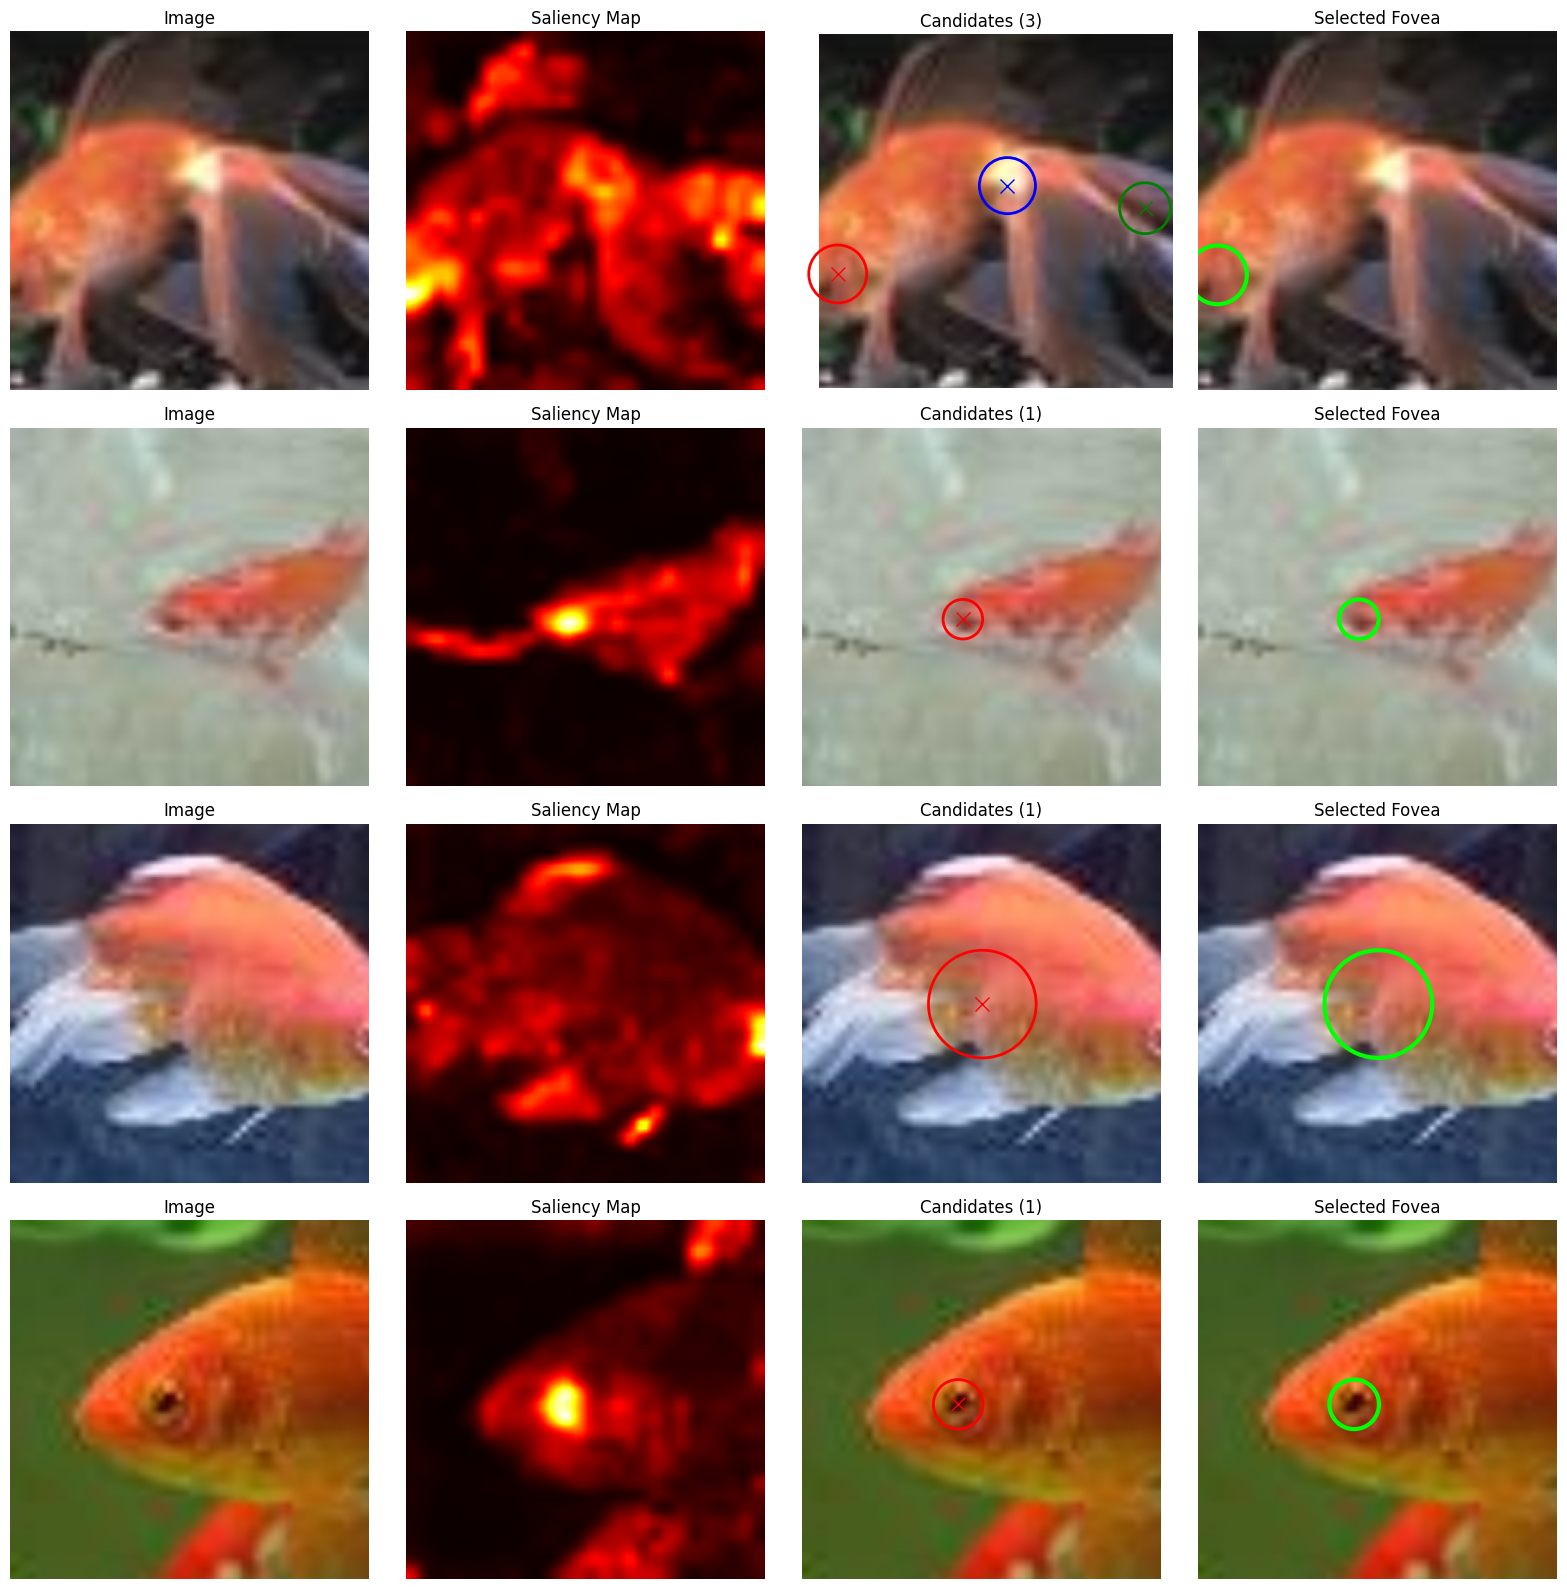

In [ ]:
# Get a small batch for visualization
viz_batch = next(iter(val_loader))
viz_images, viz_labels = viz_batch[0][:8].to(device), viz_batch[1][:8]

# Compute saliency
with torch.no_grad():
    saliency_maps = saliency_oracle(viz_images, target_size=(56, 56))

# Extract candidates
candidates_list = batch_extract_fovea_candidates(saliency_maps, cfg)
selected_circles = select_fovea_for_batch(candidates_list, training=False)

# Run through model with extras
model.eval()
with torch.no_grad():
    logits, features, degraded, weight_map, dist_map, noise_std_map = \
        model.forward_with_extras(viz_images, selected_circles)

print(f'Features shape: {features.shape}')
print(f'Weight map shape: {weight_map.shape}')
print(f'Noise std map range: [{noise_std_map.min():.4f}, {noise_std_map.max():.4f}]')
print(f'Number of candidates per image: {[len(c) for c in candidates_list]}')

# Plot fovea analysis
plot_fovea_analysis(viz_images, saliency_maps, candidates_list, selected_circles,
                    n_show=4, save_path=os.path.join(cfg.output_dir, 'fovea_analysis.png'))

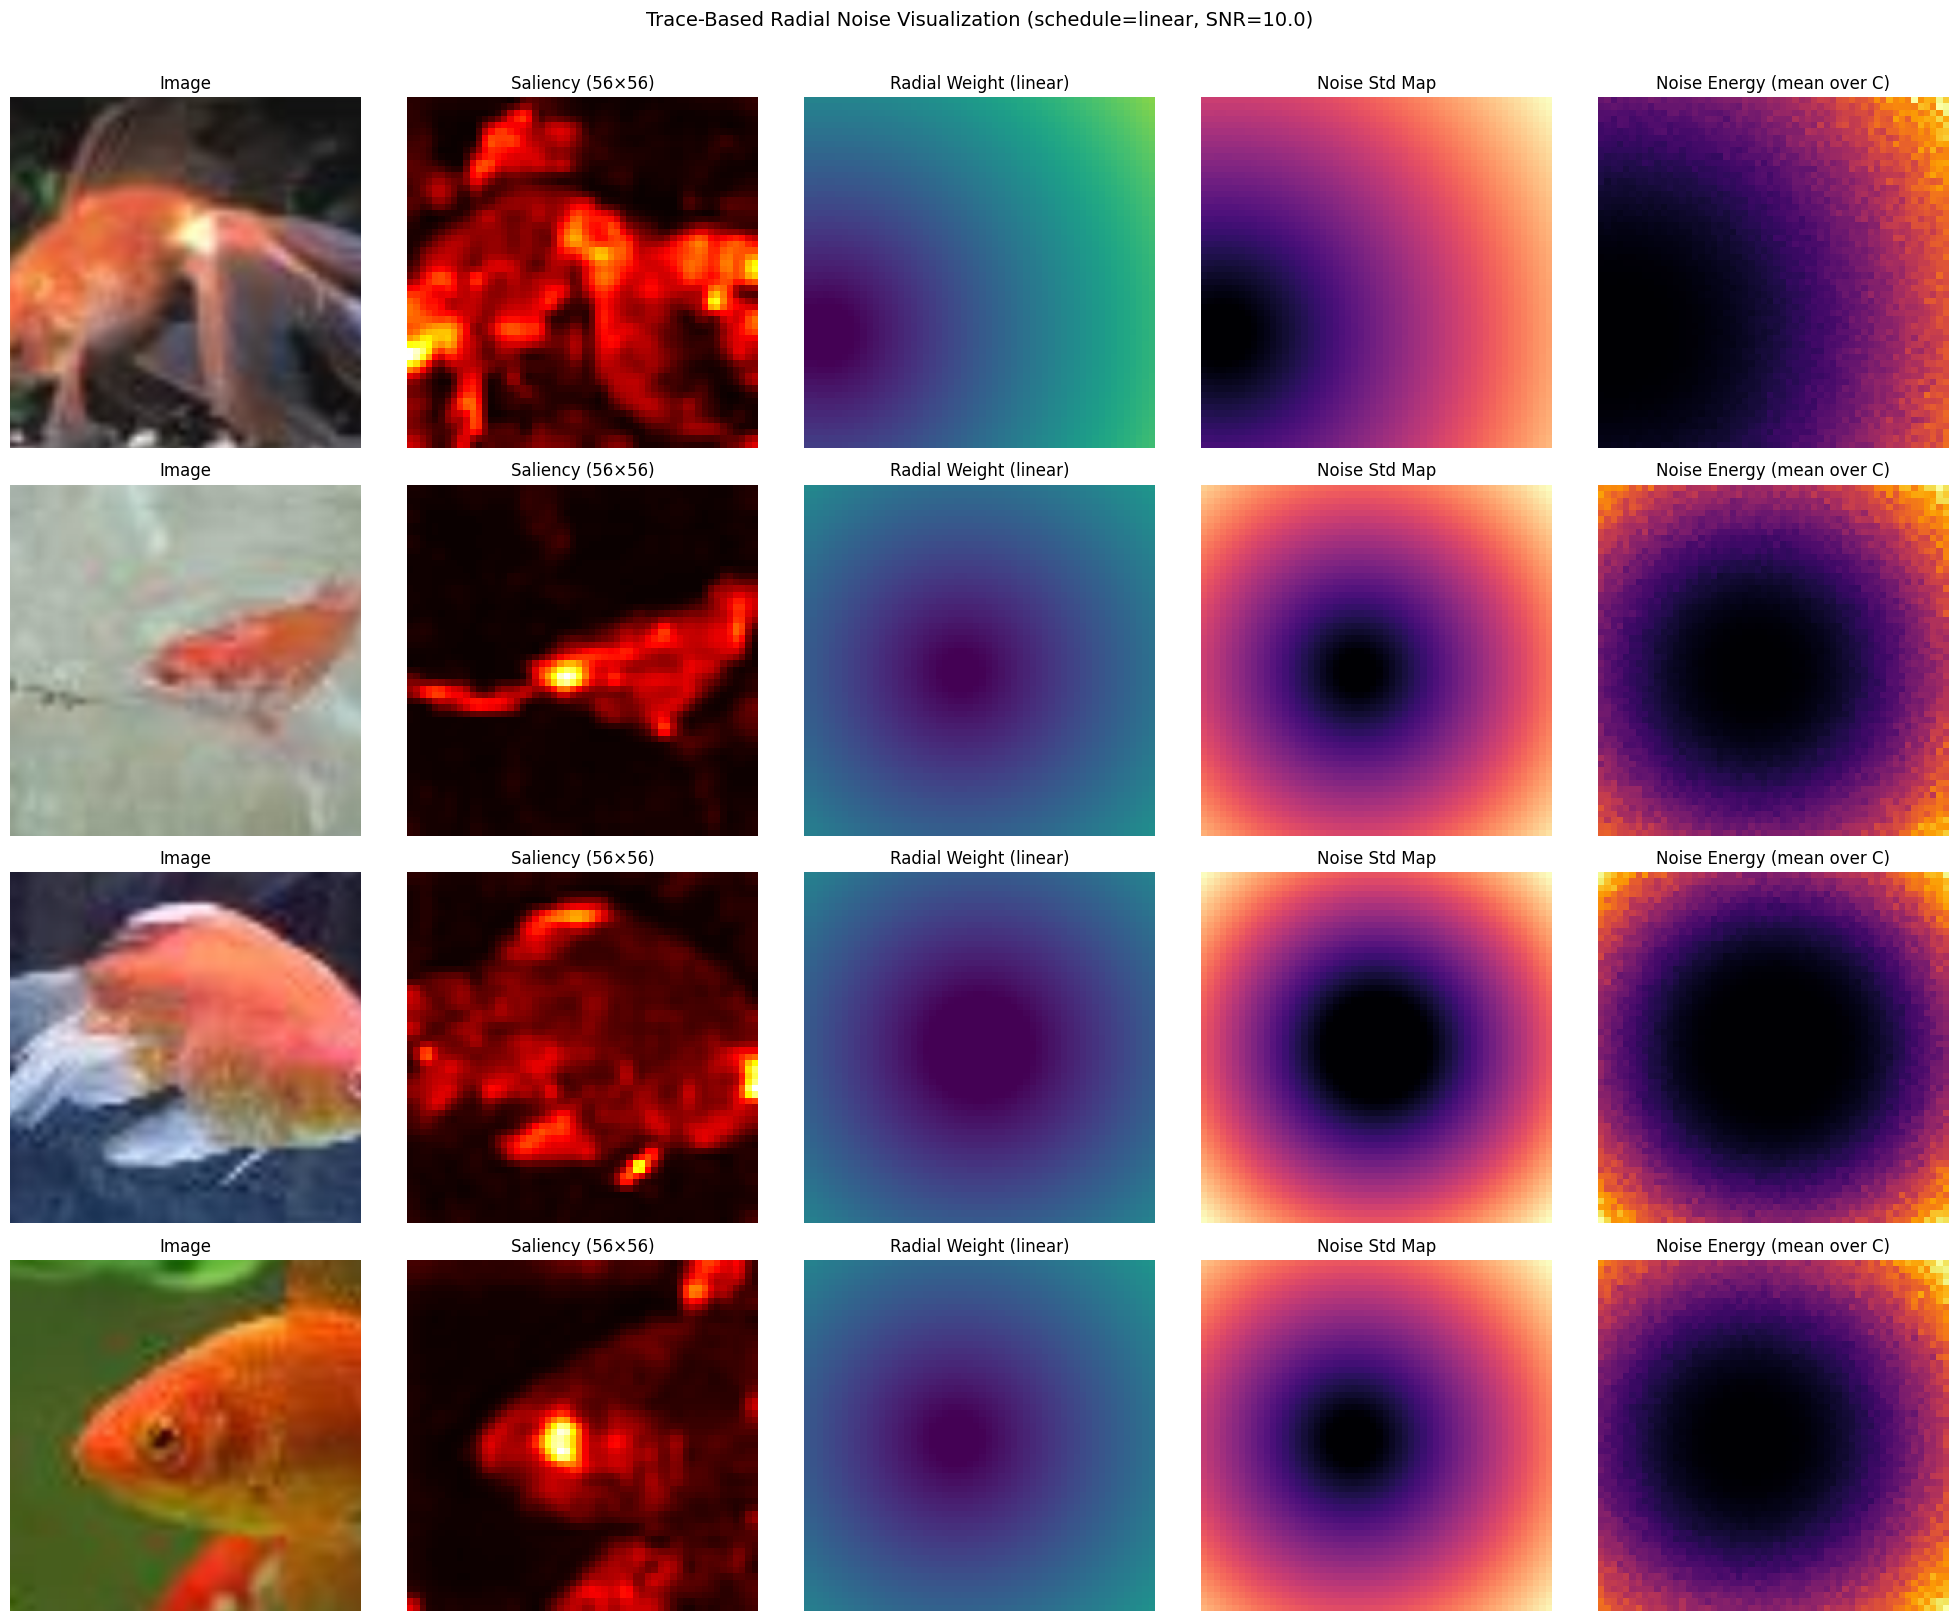


--- Inverted Fovea Example ---


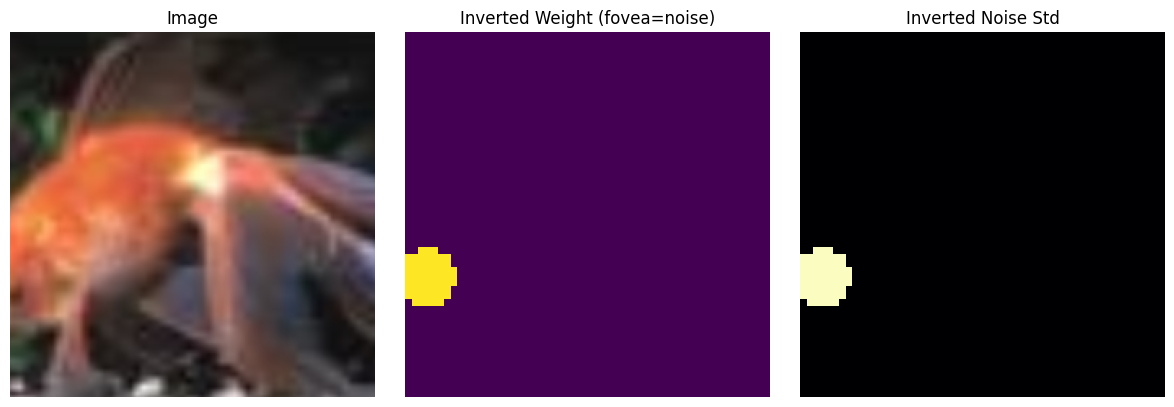

In [ ]:
# Visualize radial weight maps and noise std maps
mean_np = np.array([0.485, 0.456, 0.406])
std_np = np.array([0.229, 0.224, 0.225])

n_show = min(4, len(viz_images))
fig, axes = plt.subplots(n_show, 5, figsize=(20, 4 * n_show))
if n_show == 1:
    axes = axes[None, :]

for i in range(n_show):
    img = viz_images[i].cpu().numpy().transpose(1, 2, 0)
    img = (img * std_np + mean_np).clip(0, 1)

    axes[i, 0].imshow(img)
    axes[i, 0].set_title('Image')
    axes[i, 0].axis('off')

    sal = saliency_maps[i].cpu().numpy()
    axes[i, 1].imshow(sal, cmap='hot')
    axes[i, 1].set_title('Saliency (56×56)')
    axes[i, 1].axis('off')

    wm = weight_map[i, 0].cpu().numpy()
    axes[i, 2].imshow(wm, cmap='viridis', vmin=0, vmax=1)
    axes[i, 2].set_title(f'Radial Weight ({cfg.radial_schedule})')
    axes[i, 2].axis('off')

    nsm = noise_std_map[i, 0].cpu().numpy()
    axes[i, 3].imshow(nsm, cmap='magma')
    axes[i, 3].set_title('Noise Std Map')
    axes[i, 3].axis('off')

    # Feature energy difference
    feat_diff = (degraded[i] - features[i]).pow(2).mean(dim=0).cpu().numpy()
    axes[i, 4].imshow(feat_diff, cmap='inferno')
    axes[i, 4].set_title('Noise Energy (mean over C)')
    axes[i, 4].axis('off')

plt.suptitle(f'Trace-Based Radial Noise Visualization (schedule={cfg.radial_schedule}, SNR={cfg.target_snr})',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(cfg.output_dir, 'noise_visualization.png'), dpi=100, bbox_inches='tight')
plt.show()

# Show inverted fovea example
print('\n--- Inverted Fovea Example ---')
noise_inv = TraceRadialNoise(target_snr=cfg.target_snr, schedule=cfg.radial_schedule, invert_fovea=True).to(device)
noise_inv.eval()
with torch.no_grad():
    deg_inv, wm_inv, _, nsm_inv = noise_inv(features[:2], selected_circles[:2])

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(viz_images[0].cpu().numpy().transpose(1, 2, 0) * std_np + mean_np)
axes[0].set_title('Image')
axes[0].axis('off')
axes[1].imshow(wm_inv[0, 0].cpu().numpy(), cmap='viridis')
axes[1].set_title('Inverted Weight (fovea=noise)')
axes[1].axis('off')
axes[2].imshow(nsm_inv[0, 0].cpu().numpy(), cmap='magma')
axes[2].set_title('Inverted Noise Std')
axes[2].axis('off')
plt.tight_layout()
plt.savefig(os.path.join(cfg.output_dir, 'inverted_fovea.png'), dpi=100, bbox_inches='tight')
plt.show()

## 12. Training Loop

In [ ]:
def train_one_epoch(model, saliency_oracle, train_loader, optimizer, scaler, cfg, epoch):
    model.train()
    # Keep VOneBlock in eval mode (frozen BN if any)
    model.vone_block.eval()

    total_loss = 0.0
    correct = 0
    total = 0
    criterion = nn.CrossEntropyLoss()

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        # Compute fovea circles (random selection during training)
        fovea_circles = compute_fovea_for_batch(images, saliency_oracle, cfg, training=True)

        optimizer.zero_grad()

        if cfg.mixed_precision:
            with autocast():
                logits = model(images, fovea_circles)
                loss = criterion(logits, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(images, fovea_circles)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        if (batch_idx + 1) % 50 == 0:
            print(f'  Batch {batch_idx+1}/{len(train_loader)} | '
                  f'Loss: {loss.item():.4f} | Acc: {correct/total:.4f}', end='\r')

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, saliency_oracle, val_loader, cfg):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    criterion = nn.CrossEntropyLoss()

    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)

        # Eval: use top-1 most salient region
        fovea_circles = compute_fovea_for_batch(images, saliency_oracle, cfg, training=False)

        logits = model(images, fovea_circles)
        loss = criterion(logits, labels)

        total_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


def get_lr_scheduler(optimizer, cfg, steps_per_epoch):
    """Warmup + cosine annealing schedule."""
    warmup_steps = cfg.warmup_epochs * steps_per_epoch
    total_steps = cfg.epochs * steps_per_epoch

    def lr_lambda(step):
        if step < warmup_steps:
            return step / warmup_steps
        progress = (step - warmup_steps) / (total_steps - warmup_steps)
        return 0.5 * (1 + math.cos(math.pi * progress))

    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

print('Training utilities ready.')

Training utilities ready.


In [ ]:
# --- Run Training ---
set_seed(cfg.seed)

# Optimizer: only trainable params (bottleneck + backend)
trainable_params_list = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(
    trainable_params_list,
    lr=cfg.learning_rate,
    momentum=cfg.momentum,
    weight_decay=cfg.weight_decay
)

scaler = GradScaler(enabled=cfg.mixed_precision)
scheduler = get_lr_scheduler(optimizer, cfg, len(train_loader))

# Training history
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0

print(f'Starting training: {cfg.epochs} epochs, LR={cfg.learning_rate}')
print(f'Trainable parameters: {sum(p.numel() for p in trainable_params_list):,}')
print('-' * 70)

for epoch in range(cfg.epochs):
    t0 = time.time()

    train_loss, train_acc = train_one_epoch(
        model, saliency_oracle, train_loader, optimizer, scaler, cfg, epoch)

    # Step scheduler per epoch
    for _ in range(len(train_loader)):
        scheduler.step()

    val_loss, val_acc = evaluate(model, saliency_oracle, val_loader, cfg)

    # Record
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    # Save best
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'config': cfg.__dict__,
        }, os.path.join(cfg.checkpoint_dir, 'best.pth'))

    elapsed = time.time() - t0
    lr = optimizer.param_groups[0]['lr']
    print(f'Epoch {epoch+1:3d}/{cfg.epochs} | '
          f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | '
          f'LR: {lr:.6f} | Time: {elapsed:.1f}s'
          + (' *' if val_acc >= best_val_acc else ''))

print('-' * 70)
print(f'Training complete. Best val accuracy: {best_val_acc:.4f}')

Starting training: 50 epochs, LR=0.05
Trainable parameters: 11,302,344
----------------------------------------------------------------------
Epoch   1/50 | Train Loss: 5.4066 Acc: 0.0050 | Val Loss: 5.3981 Acc: 0.0051 | LR: 0.010000 | Time: 539.8s *
Epoch   2/50 | Train Loss: 4.7095 Acc: 0.0569 | Val Loss: 4.5504 Acc: 0.0813 | LR: 0.020000 | Time: 538.9s *
Epoch   3/50 | Train Loss: 3.9613 Acc: 0.1465 | Val Loss: 3.7646 Acc: 0.1642 | LR: 0.030000 | Time: 538.4s *
Epoch   4/50 | Train Loss: 3.5166 Acc: 0.2140 | Val Loss: 3.5542 Acc: 0.2101 | LR: 0.040000 | Time: 538.5s *
Epoch   5/50 | Train Loss: 3.1854 Acc: 0.2718 | Val Loss: 3.4454 Acc: 0.2307 | LR: 0.050000 | Time: 538.4s *
Epoch   6/50 | Train Loss: 2.9258 Acc: 0.3184 | Val Loss: 3.1755 Acc: 0.2780 | LR: 0.049939 | Time: 538.3s *
Epoch   7/50 | Train Loss: 2.6434 Acc: 0.3724 | Val Loss: 2.7301 Acc: 0.3557 | LR: 0.049757 | Time: 538.2s *
Epoch   8/50 | Train Loss: 2.4460 Acc: 0.4119 | Val Loss: 2.8495 Acc: 0.3501 | LR: 0.049454 | T

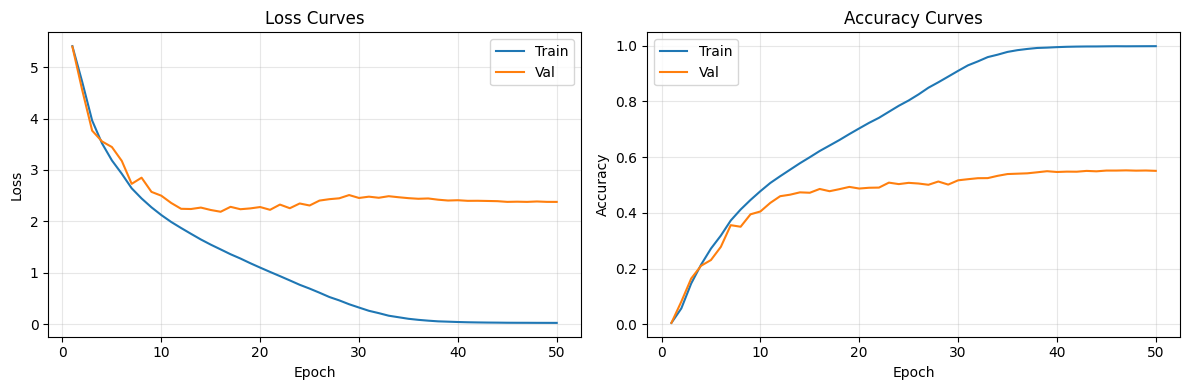

In [ ]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs_range = range(1, len(history['train_loss']) + 1)

ax1.plot(epochs_range, history['train_loss'], label='Train')
ax1.plot(epochs_range, history['val_loss'], label='Val')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss Curves')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, history['train_acc'], label='Train')
ax2.plot(epochs_range, history['val_acc'], label='Val')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy Curves')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(cfg.output_dir, 'training_curves.png'), dpi=100)
plt.show()

## 13. Robustness Evaluation on Tiny-ImageNet-C

In [ ]:
# Load best checkpoint
ckpt_path = os.path.join(cfg.checkpoint_dir, 'best.pth')
if os.path.exists(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt['model_state_dict'])
    print(f'Loaded best checkpoint (epoch {ckpt["epoch"]+1}, val_acc={ckpt["val_acc"]:.4f})')
else:
    print('No checkpoint found, using current model state.')

# Run Tiny-ImageNet-C evaluation
print('\n' + '=' * 70)
print('TINY-IMAGENET-C ROBUSTNESS EVALUATION')
print('=' * 70)

tic_results = evaluate_tinyimagenetc(
    model, saliency_oracle, cfg,
    fovea_fn=compute_fovea_for_batch
)

if tic_results is not None:
    # Summary table
    print('\n' + '=' * 70)
    print(f'{"Corruption":25s} | {"Sev 1":>6s} {"Sev 2":>6s} {"Sev 3":>6s} {"Sev 4":>6s} {"Sev 5":>6s} | {"Mean":>6s}')
    print('-' * 70)

    all_means = []
    for corruption in CORRUPTIONS:
        if corruption not in tic_results or not tic_results[corruption]:
            continue
        sevs = tic_results[corruption]
        vals = [sevs.get(s, 0) for s in range(1, 6)]
        mean_acc = np.mean(vals)
        all_means.append(mean_acc)
        vals_str = ' '.join([f'{v:.4f}' for v in vals])
        print(f'{corruption:25s} | {vals_str} | {mean_acc:.4f}')

    if all_means:
        print('-' * 70)
        print(f'{"MEAN CORRUPTION ACC":25s} | {" " * 36} | {np.mean(all_means):.4f}')
        print(f'{"MEAN CORRUPTION ERROR":25s} | {" " * 36} | {1 - np.mean(all_means):.4f}')
    print('=' * 70)

Loaded best checkpoint (epoch 47, val_acc=0.5524)

TINY-IMAGENET-C ROBUSTNESS EVALUATION
  gaussian_noise            | mean acc: 0.2466
  shot_noise                | mean acc: 0.2866
  impulse_noise             | mean acc: 0.2530
  defocus_blur              | mean acc: 0.1553
  glass_blur                | mean acc: 0.1755
  motion_blur               | mean acc: 0.1936
  zoom_blur                 | mean acc: 0.1841
  snow                      | mean acc: 0.2171
  frost                     | mean acc: 0.2154
  fog                       | mean acc: 0.1948
  brightness                | mean acc: 0.2488
  contrast                  | mean acc: 0.0729
  elastic_transform         | mean acc: 0.2527
  pixelate                  | mean acc: 0.3469
  jpeg_compression          | mean acc: 0.3305

Corruption                |  Sev 1  Sev 2  Sev 3  Sev 4  Sev 5 |   Mean
----------------------------------------------------------------------
gaussian_noise            | 0.3897 0.3288 0.2320 0.1671 0.1152

## 14. Ablation Baselines

To isolate the contribution of each component, we train and evaluate two ablation baselines on the **same data and same hyperparameters**:

| Model | VOneBlock | Radial Noise | Saliency Oracle |
|-------|-----------|--------------|-----------------|
| **Plain ResNet18** | ✗ | ✗ | ✗ |
| **VOneNet (no noise)** | ✓ (frozen) | ✗ | ✗ |
| **FoveatedVOneNet** (ours) | ✓ (frozen) | ✓ | ✓ |

This allows us to demonstrate:
- VOneBlock alone provides some robustness (Gabor front-end acts as a frequency filter)
- Trace-based radial noise adds further noise corruption robustness
- Saliency-guided fovea preserves task-relevant regions

In [ ]:
# ============================================================
# Ablation Model 1: Plain ResNet18 (no VOneBlock, no noise)
# ============================================================

class PlainResNet18(nn.Module):
    """Standard ResNet18 baseline with appropriate conv1 for 224×224 input."""

    def __init__(self, num_classes=200):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.inplanes = 64
        self.layer1 = self._make_layer(BasicBlock, 64, 2)
        self.layer2 = self._make_layer(BasicBlock, 128, 2, stride=2)
        self.layer3 = self._make_layer(BasicBlock, 256, 2, stride=2)
        self.layer4 = self._make_layer(BasicBlock, 512, 2, stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def _make_layer(self, block, planes, blocks, stride=1):
        downsample = None
        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                conv1x1(self.inplanes, planes * block.expansion, stride),
                nn.BatchNorm2d(planes * block.expansion),
            )
        layers = [block(self.inplanes, planes, stride, downsample)]
        self.inplanes = planes * block.expansion
        for _ in range(1, blocks):
            layers.append(block(self.inplanes, planes))
        return nn.Sequential(*layers)

    def forward(self, x, fovea_circles=None):
        """fovea_circles is ignored — kept for interface compatibility."""
        x = self.maxpool(self.relu(self.bn1(self.conv1(x))))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)


# ============================================================
# Ablation Model 2: VOneNet without noise (VOneBlock + backend, no noise)
# ============================================================

class VOneNetNoNoise(nn.Module):
    """VOneBlock front-end + ResNet backend, but NO radial noise."""

    def __init__(self, cfg):
        super().__init__()
        self.vone_block = build_vone_block(cfg)
        out_ch = cfg.simple_channels + cfg.complex_channels
        self.bottleneck = nn.Conv2d(out_ch, 64, kernel_size=1, stride=1, bias=False)
        nn.init.kaiming_normal_(self.bottleneck.weight, mode='fan_out', nonlinearity='relu')

        if cfg.backend == 'resnet18':
            layers = [2, 2, 2, 2]
        else:
            layers = [3, 4, 6, 3]
        self.backend = ResNetBackEnd(BasicBlock, layers, num_classes=cfg.num_classes)

    def forward(self, x, fovea_circles=None):
        """fovea_circles is ignored — no noise applied."""
        features = self.vone_block(x)
        out = self.bottleneck(features)
        return self.backend(out)


# Build ablation models
ablation_plain = PlainResNet18(num_classes=cfg.num_classes).to(device)
ablation_vonenet = VOneNetNoNoise(cfg).to(device)

print('Ablation models built:')
print(f'  PlainResNet18: {sum(p.numel() for p in ablation_plain.parameters() if p.requires_grad):,} trainable params')
print(f'  VOneNetNoNoise: {sum(p.numel() for p in ablation_vonenet.parameters() if p.requires_grad):,} trainable params')

Ablation models built:
  PlainResNet18: 11,279,112 trainable params
  VOneNetNoNoise: 11,302,344 trainable params


In [ ]:
# ============================================================
# Train Ablation Models (same hyperparameters, same data)
# ============================================================

def train_ablation_model(ablation_model, model_name, train_loader, val_loader, cfg):
    """Train an ablation model with the same config as the main model."""
    set_seed(cfg.seed)
    ablation_model.train()

    trainable_params = [p for p in ablation_model.parameters() if p.requires_grad]
    optimizer = torch.optim.SGD(
        trainable_params, lr=cfg.learning_rate,
        momentum=cfg.momentum, weight_decay=cfg.weight_decay)
    scaler = GradScaler(enabled=cfg.mixed_precision)
    scheduler = get_lr_scheduler(optimizer, cfg, len(train_loader))
    criterion = nn.CrossEntropyLoss()

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0.0
    ckpt_path = os.path.join(cfg.checkpoint_dir, f'best_{model_name}.pth')

    print(f'\n{"=" * 70}')
    print(f'Training {model_name} ({sum(p.numel() for p in trainable_params):,} params)')
    print(f'{"=" * 70}')

    for epoch in range(cfg.epochs):
        t0 = time.time()
        ablation_model.train()
        # Keep vone_block in eval if present
        if hasattr(ablation_model, 'vone_block'):
            ablation_model.vone_block.eval()

        total_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            if cfg.mixed_precision:
                with autocast():
                    logits = ablation_model(images)
                    loss = criterion(logits, labels)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                logits = ablation_model(images)
                loss = criterion(logits, labels)
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * images.size(0)
            correct += (logits.argmax(1) == labels).sum().item()
            total += labels.size(0)

        for _ in range(len(train_loader)):
            scheduler.step()

        train_loss = total_loss / total
        train_acc = correct / total

        # Validation
        ablation_model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                logits = ablation_model(images)
                loss = criterion(logits, labels)
                val_loss += loss.item() * images.size(0)
                val_correct += (logits.argmax(1) == labels).sum().item()
                val_total += labels.size(0)
        val_loss /= val_total
        val_acc = val_correct / val_total

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({'epoch': epoch, 'model_state_dict': ablation_model.state_dict(),
                        'val_acc': val_acc}, ckpt_path)

        elapsed = time.time() - t0
        print(f'  Epoch {epoch+1:3d}/{cfg.epochs} | '
              f'Train: {train_acc:.4f} | Val: {val_acc:.4f} | '
              f'Time: {elapsed:.1f}s' + (' *' if val_acc >= best_val_acc else ''))

    print(f'{model_name} best val accuracy: {best_val_acc:.4f}')
    # Reload best
    ckpt = torch.load(ckpt_path, map_location=device)
    ablation_model.load_state_dict(ckpt['model_state_dict'])
    return history, best_val_acc


# Train PlainResNet18
history_plain, best_acc_plain = train_ablation_model(
    ablation_plain, 'plain_resnet18', train_loader, val_loader, cfg)

# Train VOneNet (no noise)
history_vonenet, best_acc_vonenet = train_ablation_model(
    ablation_vonenet, 'vonenet_nonoise', train_loader, val_loader, cfg)

print(f'\n{"=" * 70}')
print('Ablation Training Complete')
print(f'  PlainResNet18 best val acc:    {best_acc_plain:.4f}')
print(f'  VOneNet (no noise) best val:   {best_acc_vonenet:.4f}')
print(f'  FoveatedVOneNet best val:      {best_val_acc:.4f}')
print(f'{"=" * 70}')


Training plain_resnet18 (11,279,112 params)
  Epoch   1/50 | Train: 0.0060 | Val: 0.0065 | Time: 62.8s *
  Epoch   2/50 | Train: 0.0836 | Val: 0.1194 | Time: 63.0s *
  Epoch   3/50 | Train: 0.1787 | Val: 0.2042 | Time: 62.9s *
  Epoch   4/50 | Train: 0.2553 | Val: 0.2298 | Time: 63.0s *
  Epoch   5/50 | Train: 0.3191 | Val: 0.3202 | Time: 63.3s *
  Epoch   6/50 | Train: 0.3687 | Val: 0.3545 | Time: 63.2s *
  Epoch   7/50 | Train: 0.4272 | Val: 0.3987 | Time: 62.9s *
  Epoch   8/50 | Train: 0.4658 | Val: 0.3614 | Time: 63.7s
  Epoch   9/50 | Train: 0.5008 | Val: 0.4272 | Time: 62.7s *
  Epoch  10/50 | Train: 0.5320 | Val: 0.4540 | Time: 62.9s *
  Epoch  11/50 | Train: 0.5586 | Val: 0.4719 | Time: 63.1s *
  Epoch  12/50 | Train: 0.5831 | Val: 0.4934 | Time: 62.7s *
  Epoch  13/50 | Train: 0.6074 | Val: 0.5141 | Time: 62.7s *
  Epoch  14/50 | Train: 0.6292 | Val: 0.4953 | Time: 62.6s
  Epoch  15/50 | Train: 0.6528 | Val: 0.5035 | Time: 63.0s
  Epoch  16/50 | Train: 0.6727 | Val: 0.5168 |

In [ ]:
# ============================================================
# Evaluate Ablation Models on Tiny-ImageNet-C
# ============================================================

def evaluate_ablation_tinyimagenetc(ablation_model, model_name, cfg):
    """Evaluate an ablation model (no saliency needed) on TI-C."""
    if not os.path.exists(cfg.tiny_imagenet_c_path):
        print(f'Tiny-ImageNet-C not found. Skipping {model_name}.')
        return None

    # Determine valid classes for debug mode
    valid_classes = None
    if cfg.train_subset_debug:
        train_dir = os.path.join(cfg.tiny_imagenet_path, 'train')
        if os.path.exists(train_dir):
            all_classes = sorted(os.listdir(train_dir))
            all_classes = [c for c in all_classes if os.path.isdir(os.path.join(train_dir, c))]
            valid_classes = sorted(all_classes)[:cfg.debug_num_classes]

    ablation_model.eval()
    results = {}

    print(f'\nEvaluating {model_name} on Tiny-ImageNet-C...')
    for corruption in CORRUPTIONS:
        results[corruption] = {}
        for severity in range(1, 6):
            loader = get_tinyimagenetc_loader(cfg, corruption, severity, valid_classes)
            if loader is None:
                continue
            correct, total = 0, 0
            with torch.no_grad():
                for images, labels in loader:
                    images, labels = images.to(device), labels.to(device)
                    logits = ablation_model(images)
                    correct += (logits.argmax(1) == labels).sum().item()
                    total += labels.size(0)
            results[corruption][severity] = correct / total if total > 0 else 0.0
        if results[corruption]:
            mean_acc = np.mean(list(results[corruption].values()))
            print(f'  {corruption:25s} | mean acc: {mean_acc:.4f}')

    return results


# Evaluate both ablation models
print('=' * 70)
print('ABLATION TI-C EVALUATION')
print('=' * 70)

tic_results_plain = evaluate_ablation_tinyimagenetc(ablation_plain, 'PlainResNet18', cfg)
tic_results_vonenet = evaluate_ablation_tinyimagenetc(ablation_vonenet, 'VOneNet (no noise)', cfg)

ABLATION TI-C EVALUATION

Evaluating PlainResNet18 on Tiny-ImageNet-C...
  gaussian_noise            | mean acc: 0.1811
  shot_noise                | mean acc: 0.2213
  impulse_noise             | mean acc: 0.1867
  defocus_blur              | mean acc: 0.1275
  glass_blur                | mean acc: 0.1424
  motion_blur               | mean acc: 0.1791
  zoom_blur                 | mean acc: 0.1493
  snow                      | mean acc: 0.2349
  frost                     | mean acc: 0.2503
  fog                       | mean acc: 0.2355
  brightness                | mean acc: 0.2930
  contrast                  | mean acc: 0.0970
  elastic_transform         | mean acc: 0.2411
  pixelate                  | mean acc: 0.3704
  jpeg_compression          | mean acc: 0.3226

Evaluating VOneNet (no noise) on Tiny-ImageNet-C...
  gaussian_noise            | mean acc: 0.1869
  shot_noise                | mean acc: 0.2267
  impulse_noise             | mean acc: 0.1979
  defocus_blur              


ABLATION COMPARISON — Tiny-ImageNet-C Mean Accuracy
Category     |  PlainResNet18 |  VOneNet(no noise) | FoveatedVOneNet |  Δ(Ours-Plain)
--------------------------------------------------------------------------------
Noise        |         0.1964 |             0.2038 |          0.2620 |        +0.0657 ✓
Blur         |         0.1496 |             0.1602 |          0.1771 |        +0.0276 ✓
Weather      |         0.2534 |             0.2349 |          0.2190 |        -0.0344
Digital      |         0.2578 |             0.2545 |          0.2508 |        -0.0070
Overall      |         0.2155 |             0.2140 |          0.2249 |        +0.0094 ✓

Clean Validation Accuracy:
  PlainResNet18:      0.5862
  VOneNet (no noise): 0.5790
  FoveatedVOneNet:    0.5524


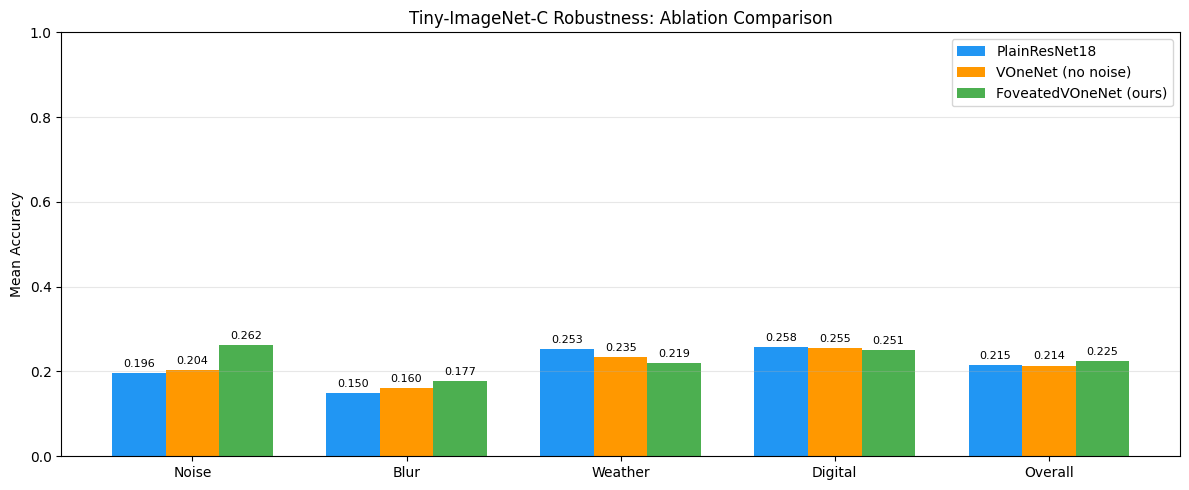

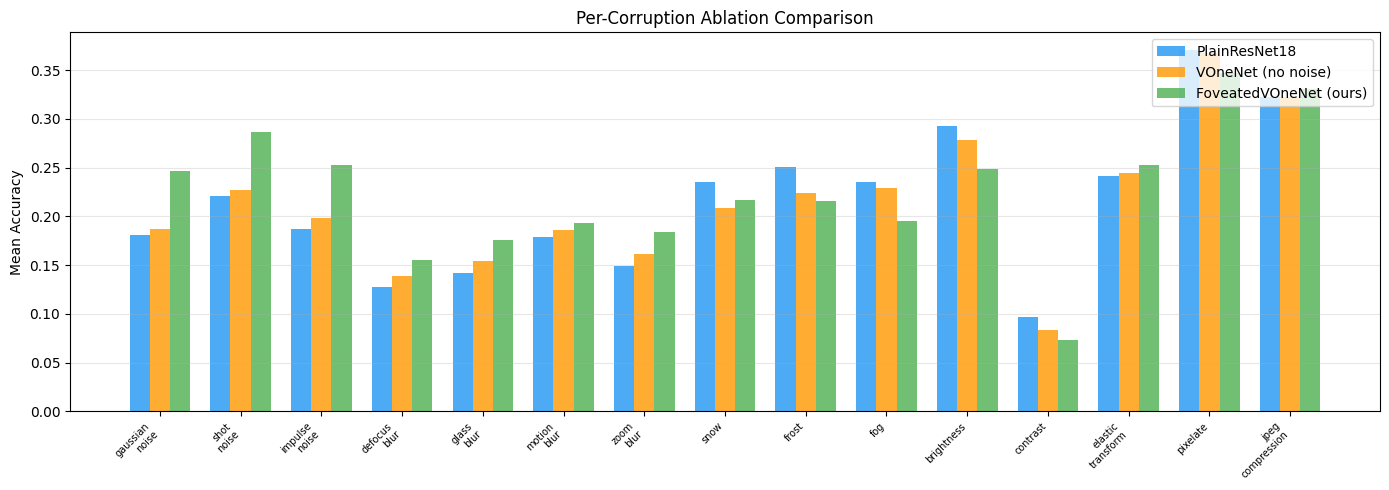

In [ ]:
# ============================================================
# Comparison Table & Visualization
# ============================================================

def compute_category_means(results):
    """Compute mean accuracy per corruption category."""
    if results is None:
        return {}
    categories = {
        'Noise': ['gaussian_noise', 'shot_noise', 'impulse_noise'],
        'Blur': ['defocus_blur', 'glass_blur', 'motion_blur', 'zoom_blur'],
        'Weather': ['snow', 'frost', 'fog', 'brightness'],
        'Digital': ['contrast', 'elastic_transform', 'pixelate', 'jpeg_compression'],
    }
    cat_means = {}
    for cat_name, corruptions in categories.items():
        accs = []
        for c in corruptions:
            if c in results and results[c]:
                accs.append(np.mean(list(results[c].values())))
        cat_means[cat_name] = np.mean(accs) if accs else 0.0
    # Overall
    all_accs = [np.mean(list(v.values())) for v in results.values() if v]
    cat_means['Overall'] = np.mean(all_accs) if all_accs else 0.0
    return cat_means


# Compute category-level results for all 3 models
cats_foveated = compute_category_means(tic_results)
cats_plain = compute_category_means(tic_results_plain)
cats_vonenet = compute_category_means(tic_results_vonenet)

# --- Print Comparison Table ---
print('\n' + '=' * 80)
print('ABLATION COMPARISON — Tiny-ImageNet-C Mean Accuracy')
print('=' * 80)
print(f'{"Category":12s} | {"PlainResNet18":>14s} | {"VOneNet(no noise)":>18s} | {"FoveatedVOneNet":>15s} | {"Δ(Ours-Plain)":>14s}')
print('-' * 80)

for cat in ['Noise', 'Blur', 'Weather', 'Digital', 'Overall']:
    p = cats_plain.get(cat, 0)
    v = cats_vonenet.get(cat, 0)
    f = cats_foveated.get(cat, 0)
    delta = f - p
    marker = ' ✓' if delta > 0 else ''
    print(f'{cat:12s} | {p:>14.4f} | {v:>18.4f} | {f:>15.4f} | {delta:>+14.4f}{marker}')
print('=' * 80)

# --- Clean Accuracy Comparison ---
print(f'\nClean Validation Accuracy:')
print(f'  PlainResNet18:      {best_acc_plain:.4f}')
print(f'  VOneNet (no noise): {best_acc_vonenet:.4f}')
print(f'  FoveatedVOneNet:    {best_val_acc:.4f}')

# --- Bar Chart: Category-level comparison ---
categories = ['Noise', 'Blur', 'Weather', 'Digital', 'Overall']
x = np.arange(len(categories))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width, [cats_plain.get(c, 0) for c in categories], width, label='PlainResNet18', color='#2196F3')
bars2 = ax.bar(x, [cats_vonenet.get(c, 0) for c in categories], width, label='VOneNet (no noise)', color='#FF9800')
bars3 = ax.bar(x + width, [cats_foveated.get(c, 0) for c in categories], width, label='FoveatedVOneNet (ours)', color='#4CAF50')

ax.set_ylabel('Mean Accuracy')
ax.set_title('Tiny-ImageNet-C Robustness: Ablation Comparison')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend(loc='upper right')
ax.set_ylim(0, 1.0)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                       xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(cfg.output_dir, 'ablation_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

# --- Per-corruption comparison plot ---
fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(CORRUPTIONS))
width = 0.25

def get_per_corruption_means(results):
    if results is None:
        return [0] * len(CORRUPTIONS)
    return [np.mean(list(results[c].values())) if c in results and results[c] else 0
            for c in CORRUPTIONS]

means_plain = get_per_corruption_means(tic_results_plain)
means_vonenet = get_per_corruption_means(tic_results_vonenet)
means_foveated = get_per_corruption_means(tic_results)

ax.bar(x - width, means_plain, width, label='PlainResNet18', color='#2196F3', alpha=0.8)
ax.bar(x, means_vonenet, width, label='VOneNet (no noise)', color='#FF9800', alpha=0.8)
ax.bar(x + width, means_foveated, width, label='FoveatedVOneNet (ours)', color='#4CAF50', alpha=0.8)

ax.set_ylabel('Mean Accuracy')
ax.set_title('Per-Corruption Ablation Comparison')
ax.set_xticks(x)
ax.set_xticklabels([c.replace('_', '\n') for c in CORRUPTIONS], fontsize=7, rotation=45, ha='right')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(cfg.output_dir, 'ablation_per_corruption.png'), dpi=150, bbox_inches='tight')
plt.show()

## 15. Final Summary

In [ ]:
print('\n' + '=' * 70)
print('EXPERIMENT SUMMARY')
print('=' * 70)
print(f'\nModel: FoveatedVOneNet ({cfg.backend} backend)')
print(f'Dataset: Tiny-ImageNet-200{" (debug subset)" if cfg.train_subset_debug else ""}')
print(f'Epochs: {cfg.epochs}')
print(f'Radial noise schedule: {cfg.radial_schedule}')
print(f'Target SNR: {cfg.target_snr}')
print(f'Invert fovea: {cfg.invert_fovea}')
print(f'Max salient regions: {cfg.num_salient_regions_max}')

print(f'\n--- Clean Validation Accuracy ---')
print(f'  PlainResNet18:      {best_acc_plain:.4f}')
print(f'  VOneNet (no noise): {best_acc_vonenet:.4f}')
print(f'  FoveatedVOneNet:    {best_val_acc:.4f}')

print(f'\n--- Tiny-ImageNet-C Category Accuracy ---')
for cat in ['Noise', 'Blur', 'Weather', 'Digital', 'Overall']:
    p = cats_plain.get(cat, 0)
    v = cats_vonenet.get(cat, 0)
    f = cats_foveated.get(cat, 0)
    print(f'  {cat:10s} | Plain: {p:.4f} | VOneNet: {v:.4f} | Foveated: {f:.4f} | Δ={f-p:+.4f}')

print(f'\nCheckpoints saved to: {cfg.checkpoint_dir}/')
print(f'Visualizations saved to: {cfg.output_dir}/')
print('\n' + '=' * 70)
print('DONE')
print('=' * 70)


EXPERIMENT SUMMARY

Model: FoveatedVOneNet (resnet18 backend)
Dataset: Tiny-ImageNet-200
Epochs: 50
Radial noise schedule: linear
Target SNR: 10.0
Invert fovea: False
Max salient regions: 3

--- Clean Validation Accuracy ---
  PlainResNet18:      0.5862
  VOneNet (no noise): 0.5790
  FoveatedVOneNet:    0.5524

--- Tiny-ImageNet-C Category Accuracy ---
  Noise      | Plain: 0.1964 | VOneNet: 0.2038 | Foveated: 0.2620 | Δ=+0.0657
  Blur       | Plain: 0.1496 | VOneNet: 0.1602 | Foveated: 0.1771 | Δ=+0.0276
  Weather    | Plain: 0.2534 | VOneNet: 0.2349 | Foveated: 0.2190 | Δ=-0.0344
  Digital    | Plain: 0.2578 | VOneNet: 0.2545 | Foveated: 0.2508 | Δ=-0.0070
  Overall    | Plain: 0.2155 | VOneNet: 0.2140 | Foveated: 0.2249 | Δ=+0.0094

Checkpoints saved to: /content/checkpoints/
Visualizations saved to: /content/outputs/

DONE


---

## Quick-Start Notes

### How to use this notebook in Colab:
1. Upload this `.ipynb` to Google Colab or open via GitHub/Drive.
2. Set Runtime → GPU (T4 or better).
3. Run cells sequentially from top to bottom.

### Where to place Tiny-ImageNet:
- The notebook auto-downloads to `/content/data/tiny-imagenet-200/`.
- If you have it elsewhere, change `cfg.tiny_imagenet_path`.

### Where to place Tiny-ImageNet-C:
- Download from: https://zenodo.org/records/2536630
- Extract to: `/content/data/Tiny-ImageNet-C/`
- Expected layout: `<corruption_name>/<severity>/<class>/*.JPEG`
- If not present, the evaluation gracefully skips.

### Switching from smoke test to full training:
- Set `cfg.train_subset_debug = False` in the Config cell.
- Increase `cfg.epochs` (e.g., 30–50).
- Increase `cfg.batch_size` if GPU memory allows (128+).
- The model will then train on all 200 classes.

### Changing the radial schedule:
- Set `cfg.radial_schedule` to `'linear'`, `'quadratic'`, or `'exponential'`.

### Enabling inverted-fovea mode:
- Set `cfg.invert_fovea = True` — this degrades the fovea and preserves the periphery.